# GPS adatokból a mozgás kinematikai paramétereinek számolása, simítással

## Fizika informatikusoknak géptermi gyakorlat

v 2026/0.8

Ez a notebook épít a korább GPS adatbeolvasóban és a többdimenziós kinematikai számításokban szerzett tudásra.


In [2]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    
import pandas as pd   # Pandas, csak a CSV olvasás miatt
from scipy.interpolate import make_smoothing_spline  # simító spline

# Korábbról ismert eljárások

## Általános számítási függvények

In [3]:
# Egy függvényt kiértékel a beadott tömb minden pontjában:
def calc_function(xx_tab, fun):
    return np.vectorize(fun)(xx_tab)

In [4]:
# deriváló rutin a NumPy általánosabb eljárását meghívva.

# 1 dimenziós deriváló rutin
def deriv(xx_tab, ff_tab):  # itt 'xx' az általános 'x' változót jelöli, nem az 'x' helykoordinátát!
    return np.gradient(ff_tab, xx_tab, edge_order=2)

# N dimenziós deriváló rutin. Feltételezi, hogy a 0-s tengely mentén vannak az adatok, 
# de a deriválandó függvény komponensei az 1-es tengely mentétn találhatók.
def deriv_nd(xx_tab, ff_tab):  # itt 'xx' az általános 'x' változót jelöli, nem az 'x' helykoordinátát!
    """Deriválás a 0-es tengely mentén a NumPy rutinjával."""
    return np.gradient(ff_tab, xx_tab, edge_order=1, axis=0)

In [5]:
# 1 dimenziós deriváló rutin
def integ(xx_tab, ff_tab, F0=0.0):
    intff=np.zeros_like(xx_tab)  # az integrál értékek tömbje
    intff[1:]=np.cumsum((xx_tab[1:]-xx_tab[:-1])*(ff_tab[1:]+ff_tab[:-1])/2.0)   # cumsum= felösszegzés
    intff +=F0
    return(intff)

# N dimenziós deriváló rutin. Feltételezi, hogy a 0-s tengely mentén vannak az adatok, 
# de a deriválandó függvény komponensei az 1-es tengely mentétn találhatók.
def integ_nd(xx_tab, ff_tab, F0=0.0):
    """ Trapézszabály szerinti integrálás vektorizált formában """
    
    intff = np.zeros_like(ff_tab)  # Az integrál értékek tömbje
    dx = xx_tab[1:] - xx_tab[:-1]  # Különbségek az x tengelyen
    avg_f = (ff_tab[1:] + ff_tab[:-1]) / 2.0  # Trapézszabály szerinti átlag
    
    # kumulatív összg számítása minden oszlopra egyszerre
    intff[1:] = np.cumsum(dx[:, None] * avg_f, axis=0)

    intff +=F0
    return intff

In [6]:
# Vektor-abszolútérték számítás
# Feltételezi, hogy 2D tömböt kap és az 1-es axis a vektor-komponensek tengelye.

def vect_abs(vect):
    return (vect**2).sum(axis=1) ** 0.5

In [7]:
def arg_eq(tab, value):
    """Azon 'i' indexek táblázata, mely esetén tab[i]<=value<tab[i+1] vagy tab[i]>=value>tab[i+1]."""
    eq_tab=(tab==value)   # azok az elemek, ahol épp fennál az egyenlőség
    between_tab=(tab[:-1]<value) & (value<tab[1:])  # azok az elemek, ahol az elem kisebb, mint value, de az utána levő már nagyobb
    between_tab|=(tab[:-1]>value) & (value>tab[1:]) # azok az elemek, ahol az elem nagyobb, mint value, de az utána levő már kisebb
    # összerakjuk:
    find_tab=eq_tab
    find_tab[:-1]|=between_tab
      
    return np.argwhere(find_tab).flatten()

## Kinematikai class

In [8]:
class num_kinem:
    """Ez az osztály egy általános kinematikai osztály, 
    egyenletes lépésközű időskálát alkalmazva.
    
    Attributes:
       Ndim (int): a használt tér dimenziószáma. (1, 2 vagy 3)
    """

    def __init__(self, Ndim):   # dimenziószám
        self.Ndim=Ndim
        
        # később feltöltendő elemek:
        self.t_start=None  # időtengely eleje
        self.t_end=None    # időtengely vége
        self.delta_t=None  # időlépés
        self.t=None        # időtengely tömbje
        
        # hely, sebesség, gyorsulás
        self.r=None        # helyvektorok tömbje
        self.v=None        # sebességvektorok tömbje
        self.a=None        # gyorsulásvektorok tömbje
        self.v_abs=None    # sebesség abszolútérték tömbje
        
        # elmozdulások, úthossz
        self.delta_r=None      # szomszéd elemek közti elmozdulások vektorainak tömbje
        self.delta_r_abs=None  # szomszéd elemek közti elmozdulások nagyságának tömbje
        self.pathlength=None   # útvonalhossz adatok tömbje
        
        # gyorsulással kapcsolatos paraméterek:
        self.a_t=None        # tangenciális gyorsulásértékek (előjeles) tömbje
        self.a_t_vec=None    # tangenciális gyorsulásvektorok tömbje
        self.a_cp_vec=None   # centripet. gyorsulás vektorainak tömbje
        self.a_cp=None       # centripet. gyorsulás nagyságának tömbje
        self.Rinv=None       # pályagörbület reciprok-értékeinek tömbje
        
        

    # Inicializáló eljárások
    def set_time_range(self, t_start, t_end, delta_t):
        """Az időtartomány beállítása egyenletes lépésközzel.
        
        Args: 
           t_start (float): kezdő időpont
           t_end (float): végső időpont
           delta_t (float): időlépés:
        """
        
        self.t_start=t_start
        self.t_end=t_end
        self.delta_t=delta_t

        self.t=np.arange(t_start, t_end, delta_t, np.float64)   

        
    def set_r_fun(self, fun):
        """'r' értékek beállítása függvény alapján a meglevő 't' értékekhez.
        
        Args:
           fun: r(t) függvény
        """
        self.r=np.vectorize(fun, signature="()->(n)")(self.t)

    def set_v_fun(self, fun):
        """'v' értékek beállítása függvény alapján a meglevő 't' értékekhez.
        
        Args:
           fun: v(t) függvény
        """
        self.v=np.vectorize(fun, signature="()->(n)")(self.t)

    def set_a_fun(self, fun):
        """'a' értékek beállítása függvény alapján a meglevő 't' értékekhez.
        
        Args:
           fun: a(t) függvény
        """
        self.a=np.vectorize(fun, signature="()->(n)")(self.t)

    # Kinematikai átszámítások hely, sebesség és gyorsulás között.
    def calc_r_to_v(self):
        """Helyből sebesség számítás."""
        self.v=deriv_nd(self.t, self.r)

    def calc_v_to_a(self):
        """Sebességből gyorsulás számítás."""
        self.a=deriv_nd(self.t, self.v)

    def calc_a_to_v(self, v0=0.0):
        """Gyorsulásból sebesség számolás.
        
        Args:
           v0 (float): kezdő sebességvektor
        """
        self.v=integ_nd(self.t, self.a, v0)

    def calc_v_to_r(self, r0=0.0):
        """Sebességből hely számolás.
        
        Args:
           r0 (float): kezdő helyvektor
        
        """    
        self.r=integ_nd(self.t, self.v, r0)

        
    # Szomszédok közti változások számítása
    def calc_delta_r(self):
        """Időlépések közti elmozdulás-vektorok számítása."""
        self.delta_r=self.r[1:, :]-self.r[:-1, :]

    def calc_delta_r_abs(self):
        """Időlépések közti elmozdulás-nagyságok számítása."""
        self.delta_r_abs=vect_abs(self.r[1:, :]-self.r[:-1, :])

    # útvonalhossz-számítás
    def calc_pathlength(self):
        """Úthossz a kezdeti időponttól."""
        
        self.calc_delta_r_abs()    
        self.pathlength=np.append([0],self.delta_r_abs.cumsum())


    # Tangenciális és centripetális gyorsulás, valamint görbületi a sugár reciproka. 
    # 1/R választása: egyenes pályánál R='végtelen', ami hibát jelent, de 1/R=0, ami tárolható.
    def calc_at_acp_Rinv(self,eps=1e-10):
        """Kiszámítja a tengenciális, centripetális gyorsulásokat és a görbületi sugár reciprokát."""
        self.v_abs=vect_abs(self.v)  # sebesség abszolút érték
        e_v=self.v/np.maximum(self.v_abs, eps)[:, None]   # v irányú egységvektor, null osztás elleni védelemmel
        self.a_t=(e_v*self.a).sum(axis=1)   # tangenciális gyorsulás: előjeles
        self.a_t_vec=self.a_t[:,None]*e_v   # tangenciális gyorsulás vektora
        self.a_cp_vec=self.a-self.a_t_vec   # centripet. gyorsulás vektora
        self.a_cp=vect_abs(self.a_cp_vec)   # centripet. gyorsulás nagysága
        self.Rinv=self.a_cp/np.maximum(self.v_abs, eps)**2  # görbületi sugár reciproka
    
    ################################
    # Rajzoló rutinok
    ################################
    
    # Ez nagyon egyszerű: lehetne szebbé is tenni
    def plot_simple(self, plot_list, figsize=(10,5), tlimits=None, figname=""):
        """A plot_list tartalmának plottolása t függvényében.
        
        Args:
           plot_list (list): adattömbök listája; ezek elemeit plottolja ki 
           figsize (float, float): plot mérete
           tlimits (float, float) (optional): ha meg van adva, akkor a plot t-tartományát határozza meg
           figname (str): ha meg van adva, akkor ilyen néven elmenti a plot-ot
        
        """
        fig=plt.figure(figsize=figsize)  
   
        # 
        ax1=fig.add_subplot(111) 
    
        colors=["red","green","blue","yellow","orange","magenta"]

        for i_plot, plot in enumerate(plot_list):
            ax1.plot(self.t, plot, color=colors[i_plot], label=f"#{i_plot}") 
    
        ax1.set_xlabel("$t$") 
        ax1.grid()    
        ax1.legend(loc='best')
        if tlimits is not None:  # Ha megmondták a plottolási tartományt
            ax1.set_xlim(tlimits)

        # ha adtak meg fájlnevet, akkor el is mentjük a plot-ot
        if figname!="":
            fig.savefig(figname)
            
    ######################################################x
    def plot_rva_coord(self, figsize=(10,8), tlimits=None, figname=""):
        """Hely-, sebesség- és gyorsuláskomponensek plottolása 1-1 grafikonon.
           x komponensek: red, y komponensek: green, z-komponensek: blue színnel
        
        Args:
           figsize (float, float): plot mérete
           tlimits (float, float) (optional): ha meg van adva, akkor a plot t-tartományát határozza meg
           figname (str): ha meg van adva, akkor ilyen néven elmenti a plot-ot
        """
        
        fig=plt.figure(figsize=figsize)  
    
        # három grafikon
        ax1=fig.add_subplot(311) 
        ax2=fig.add_subplot(312)
        ax3=fig.add_subplot(313)

        dim_colors=["red","green","blue"]

        dim_labels=["$x(t)$", "$y(t)$", "$z(t)$"]
        ax1.set_ylabel(",".join(dim_labels[:self.Ndim]))
        for i_dim in range(self.Ndim):
            ax1.plot(self.t, self.r[:,i_dim], color=dim_colors[i_dim], label=dim_labels[i_dim]) 

        dim_labels=["$v_x(t)$", "$v_y(t)$", "$v_z(t)$"]
        ax2.set_ylabel(",".join(dim_labels[:self.Ndim]))
        for i_dim in range(self.Ndim):
            ax2.plot(self.t, self.v[:,i_dim], color=dim_colors[i_dim], label=dim_labels[i_dim]) 

        dim_labels=["$a_x(t)$", "$a_y(t)$", "$a_z(t)$"]
        ax3.set_ylabel(",".join(dim_labels[:self.Ndim]))
        for i_dim in range(self.Ndim):
            ax3.plot(self.t, self.a[:,i_dim], color=dim_colors[i_dim], label=dim_labels[i_dim]) 
    
        # vízszintes tengelyek, rács és felirat
        for ax in [ax1, ax2, ax3]:
            ax.set_xlabel("$t$") 
            ax.grid()    
            ax.legend(loc='best')
            if tlimits is not None:  # Ha megmondták a plottolási tartományt
                ax.set_xlim(tlimits)

        # ha adtak meg fájlnevet, akkor el is mentjük a plot-ot
        if figname!="":
            fig.savefig(figname)
            
    ########################################################
    def plot_rcomp(self, figsize=(10,10), coords=[[0,1]], equal=True, figname=""):
        """Helykoordináták közül a kiválasztott párok plottolása.
        
        Args:
           figsize (float, float): plot mérete
           coords (list): hányas sorszámú koordináta-párokat plottolja
           equal (boolean): kell-e ügyelni az aznos skálázásra tengelyenként?
           figname (str): ha meg van adva, akkor ilyen néven elmenti a plot-ot
        """
        fig=plt.figure(figsize=figsize)  

        dim_labels=["$x(t)$", "$y(t)$", "$z(t)$"]
        N_ax=len(coords)  # ennyi grafikont kértek
        for i_ax in range(N_ax):  # ciklus a kiválasztott koordináta-párokra
            coord=coords[i_ax]
            ax=fig.add_subplot(N_ax,1,i_ax+1) 

            ax.plot(self.r[:,coord[0]], self.r[:,coord[1]], color="magenta")
            ax.set_xlabel(dim_labels[coord[0]]) 
            ax.set_ylabel(dim_labels[coord[1]]) 
            ax.grid()    

            # ha a tengely skálázás azonosra van kérve, akkor ezt használjuk.
            if equal:
                ax.set_aspect(aspect='equal')
                
        # ha adtak meg fájlnevet, akkor el is mentjük a plot-ot
        if figname!="": 
            fig.savefig(figname)

## GPS Logger adatok olvasása

In [9]:
def GPS_Logger_to_xyt(fname, orig='first'):
    """Az 'orig'-ban specifikáltaknak megfelelő origót használva érintősíkra vetíti a GPS koordinátákat
        az 'fname' fájlból. A Földet gömb alakkal közelíti."""
    
    # CSV beolvasás
    data=pd.read_csv(fname,sep=',')
    
    # szélességből és hosszúságból közelítő x-y-t számol
    long=np.radians(data.longitude.values)
    lat=np.radians(data.latitude.values)

    # origó beállítása
    if orig=='first':
        long_0=long[0]
        lat_0=lat[0]
    elif orig=='center':
        long_0=long.mean()
        lat_0=lat.mean()
    else:
        print("Érvénytelen origó definíció.")
        return

    # Közelítő számítás: kis a Föld sugaránál sokkal kisebb pályaméretre közel igaz.
    R_F=6378000.0 # a Föld sugara m-ben
    x=(long-long_0)*np.cos(lat_0)*R_F
    y=(lat-lat_0)*R_F

    # Az időpontokat az indulástól, másodpercben számolja
    tdat=pd.to_datetime(data['date time'], format="%Y-%m-%d %H:%M:%S").to_numpy()
    t=(tdat-tdat[0])/np.timedelta64(1, 's')  

    # Pontosság kicsomagolása
    acc=data['accuracy(m)'].values

    return t, x, y, acc

## GPS adatok ⇒ num_kinem

In [10]:
def GPS_to_num_kinem(fname, orig='first'):
    """Az 'fname' fájlból olvasott GPS adatok alapján létrehoz egy 'num_kinem' objektumot."""
    
    
    # objektum létrehozása
    kinem=num_kinem(2)   # 2D kinematikai számítások
    
    # GPS adat beolvasás
    t, x, y, acc=GPS_Logger_to_xyt(fname, orig=orig)
    
    # mozgás adatok beágyazása
    kinem.t=t.copy()
        
    kinem.r=np.zeros( (kinem.t.shape[0],2), dtype=np.float64 )
    kinem.r[:,0]=x
    kinem.r[:,1]=y
    
    # az alap számítások elvégzése
    kinem.calc_r_to_v()
    kinem.calc_v_to_a()
    kinem.calc_delta_r()
    kinem.calc_pathlength()
    kinem.calc_at_acp_Rinv()
    
    # pontosság eltárolása; hátha felhasználja valaki
    kinem.acc=acc
    
    return kinem
    
    

## num_kinem objektum simítása helykoordináták alapján

In [11]:
def num_kinem_smooth_r(numkin0, dt_new, lam=None, err_report=False):
    """A bemeneti num_kinem objektum r adatait simítja, a megadott sűrűségű rácsra újraszámolja 
    és kiszámolja a sebességet, gyorsulást, útvonalhosszat, ...
    
    Args:
       numkin0: eredeti num_kinem objektum
       dt_new: az új objektum időlépése
       lam: simítás lambda paramétere
       err_report: legyen-e számítás és print-elés a simított és az eredeti értékek átlagos eltéréséről
    """
    
    N_dim=numkin0.Ndim
    
    # új num_kinem objektum
    numkinem_new=num_kinem(N_dim)
    
    # az újraszámolt időtengely
    numkinem_new.set_time_range(numkin0.t[0], numkin0.t[-1], dt_new) 
    N_time=len(numkinem_new.t)
    
    # kezdeti r, v, a adatok
    numkinem_new.r=np.zeros((N_time, N_dim), dtype=np.float64)
    numkinem_new.v=np.zeros((N_time, N_dim), dtype=np.float64)
    numkinem_new.a=np.zeros((N_time, N_dim), dtype=np.float64)
    
    # simító spline
    for i_dim in range(N_dim):
        ri_sp3=make_smoothing_spline(numkin0.t, numkin0.r[:,i_dim], lam=lam)
        vi_sp3=ri_sp3.derivative()
        ai_sp3=vi_sp3.derivative()
        
        # ez alapján számolunk helyet, sebességet, gyorsulást
        numkinem_new.r[:,i_dim]=ri_sp3(numkinem_new.t)
        numkinem_new.v[:,i_dim]=vi_sp3(numkinem_new.t)
        numkinem_new.a[:,i_dim]=ai_sp3(numkinem_new.t)
        
    # minden egyebet kiszámolunk
    numkinem_new.calc_delta_r()
    numkinem_new.calc_pathlength()
    numkinem_new.calc_at_acp_Rinv()
    
    # mennyire tér el a simított az eredetitől?
    if err_report:
        acc_RMS=((numkin0.acc**2).mean())**0.5
        acc_max=numkin0.acc.max()
        
        # eltérés az eredeti és a simított pontok közt
        delta=np.zeros((len(numkin0.t),N_dim), dtype=np.float64)
        for i_dim in range(N_dim):
            ri_sp3=make_smoothing_spline(numkin0.t, numkin0.r[:,i_dim], lam=lam)
            delta[:,i_dim]=ri_sp3(numkin0.t)-numkin0.r[:,i_dim]
        delta_abs=vect_abs(delta)
        err_max=delta_abs.max()
        err_RMS=((delta_abs**2).mean())**0.5
               
        print(f"Adatsor pontosság: RMS={acc_RMS:.3f}; MAX={acc_max:.3f}")
        print(f"Eltérés          : RMS={err_RMS:.3f}; MAX={err_max:.3f}")
    
    return numkinem_new
        

## Alkalmazások

### Séta

In [21]:
vezet=GPS_to_num_kinem('../../../GPS-Gyor-vezet-02.csv', orig='first')
vezet_sm=num_kinem_smooth_r(séta, 0.1, lam=50, err_report=True)

Adatsor pontosság: RMS=4.055; MAX=6.640
Eltérés          : RMS=1.905; MAX=7.520


Megjegyzés: a GPS adatsorok általában pontosabbak, mint az 'accuracy' értékük, mert az egy pesszimista felső becslés. 

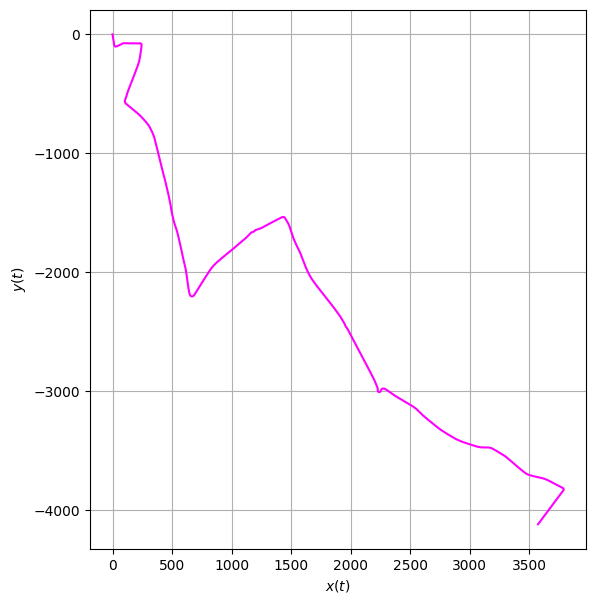

In [22]:
# eredeti pályagörbe
vezet.plot_rcomp(figsize=(7,7))

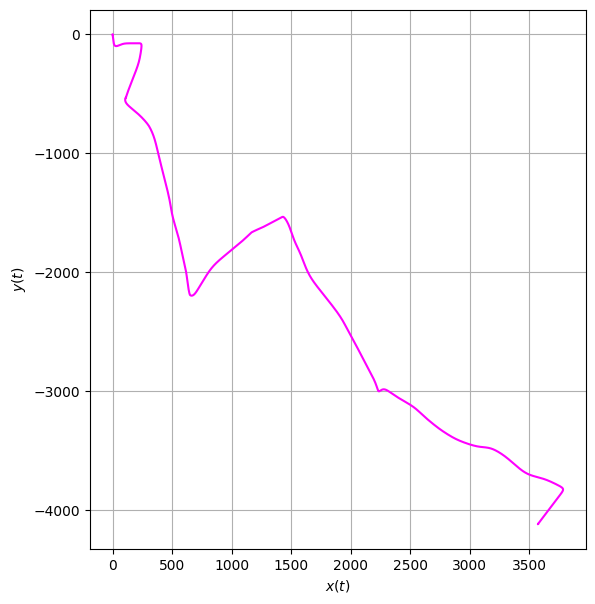

In [23]:
# simított pályagörbe
vezet_sm.plot_rcomp(figsize=(7,7))

In [19]:
# a)

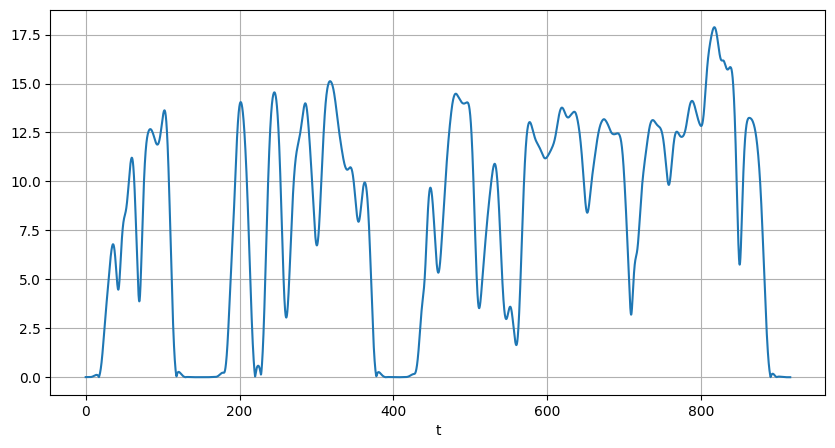

In [28]:
vezet_sm.vabs=vect_abs(vezet_sm.v)

# A sebesség-nagyság-idő függvénye:
fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vezet_sm.t, vezet_sm.vabs)
ax1.set_xlabel('t')

ax1.grid()

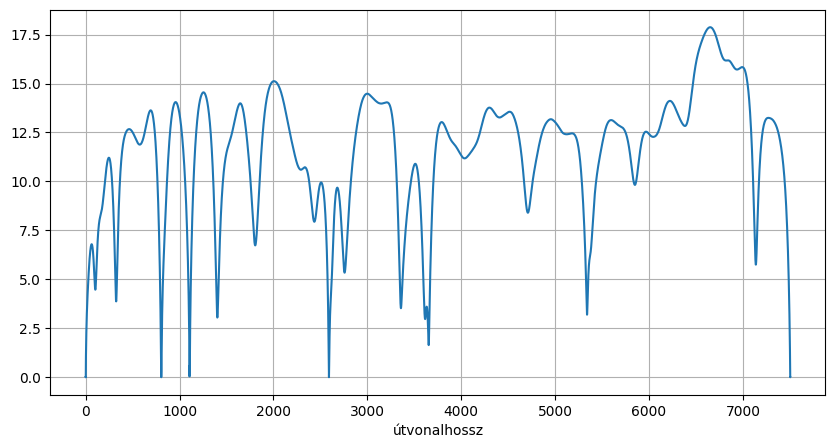

In [30]:
# A vonat sebesség-nagyság-útvonalhossz függvénye:
fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vezet_sm.pathlength, vezet_sm.vabs)
ax1.set_xlabel('útvonalhossz')

ax1.grid()

In [32]:
# b)
map_all = vezet_sm.vabs < 0.5

In [35]:
# Mennyi ideig haladt a autó 0.5 m/s-nál lassabban?

vezet_sm.vabs=vect_abs(vezet_sm.v)

map_all = vezet_sm.vabs < 0.5
t_allas=integ(vezet_sm.t, map_all*1)[-1]

print(f"Az autó összesen {t_allas:.1f} s-ig állt.")

Az autó összesen 173.1 s-ig állt.


In [50]:
# Autó pálya szürke
# Zöld amikor gyorsulás abs < 0.2
# Piros amikor gyorsulás abs > 1.5

vezet_sm.calc_v_to_a()

vezet_sm_a_abs = vect_abs(vezet_sm.a)


In [57]:
zold_szakasz = vezet_sm_a_abs < 0.2
piros_szakasz = vezet_sm_a_abs > 1.5

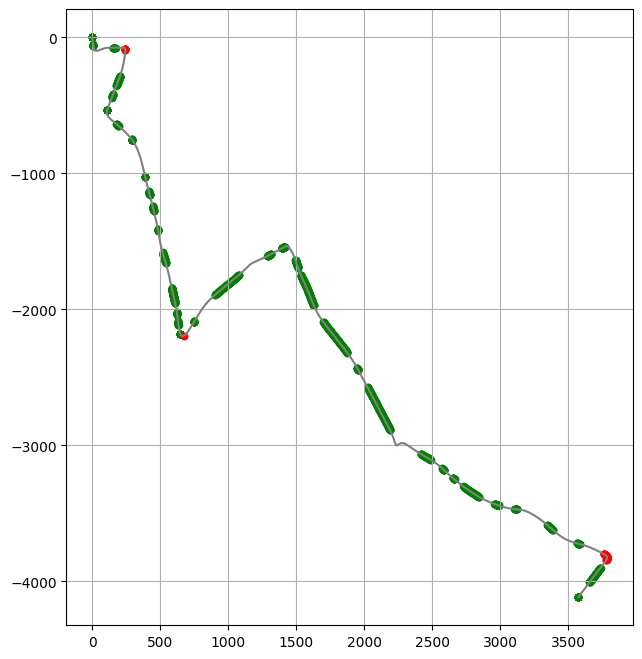

In [58]:
# hol vannak ezek a lassú helyek a térképen?

fig=plt.figure(figsize=(8,8))  
ax1=plt.subplot(111)

ax1.plot(vezet_sm.r[:,0], vezet_sm.r[:,1], color="gray")
ax1.scatter(vezet_sm.r[zold_szakasz,0], vezet_sm.r[zold_szakasz,1], color="green", s=20)
ax1.scatter(vezet_sm.r[piros_szakasz,0], vezet_sm.r[piros_szakasz,1], color="red", s=20)

ax1.set_aspect(aspect='equal')
ax1.grid()

In [88]:
teljes_út = vezet_sm.pathlength[-1]
print(teljes_út)

7503.746636502272


In [96]:
#1 szakasz 0:2290
#2 szakasz 2290:4580
#3 szakasz 4580:6870
#4 szakasz 6870:9160
#vátlag = út / idő

for i in range(4):
    q_eleje = teljes_út/4 * i
    q_vége = teljes_út / 4 * (i+1)

    ind_q_vége = arg_eq(vezet_sm.pathlength, q_vége)
    t_q_vége = vezet_sm.t[ind_q_vége]

    ind_q_eleje = arg_eq(vezet_sm.pathlength,q_eleje)
    t_q_eleje = vezet_sm.t[ind_q_eleje]

    delta_t = t_q_vége-t_q_eleje

    v_atl = teljes_út/4 / delta_t

    print(f"{delta_t}  {v_atl}")

[308.5]  [6.08083196]
[265.5]  [7.0656748]
[165.5]  [11.33496471]
[176.4]  [10.63456156]


In [76]:
# c)

vabs_work=vect_abs(vonat_sm.v)[:-1] # az utolsót lehagyjuk, mert az már a vége utánra számítana
dt_work=vonat_sm.t[1:]-vonat_sm.t[:-1]
ds_work=vonat_sm.pathlength[1:]-vonat_sm.pathlength[:-1]
# most korrigáljuk a sebességet:
vabs_korr=np.minimum(vabs_work, 15)
# korrigáljuk a menetidőt:
dt_korr=dt_work*vabs_work/vabs_korr

print("Menetidő:")
print(f"  -eredeti: {dt_work.sum():.1f} s")
print(f"  -v<15   : {dt_korr.sum():.1f} s")


NameError: name 'vonat_sm' is not defined

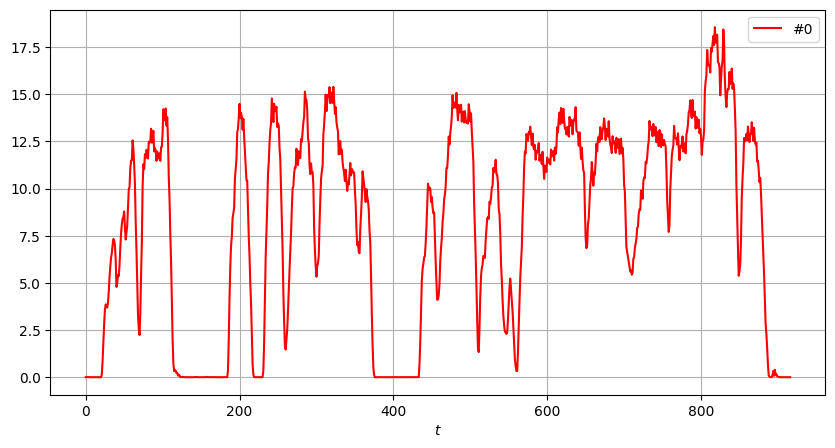

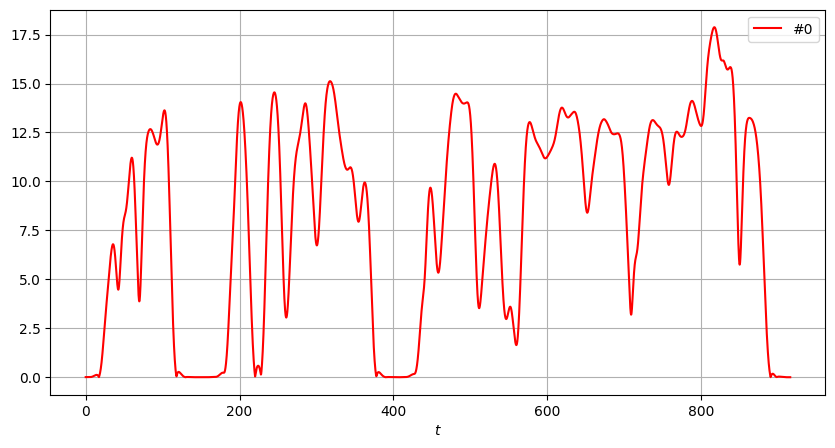

In [18]:
# sebesség nagyság az idő függvényében, eredeti
séta.v_abs=vect_abs(séta.v)
séta.plot_simple([séta.v_abs])

# ugyanez a simítottra
séta_sm.v_abs=vect_abs(séta_sm.v)
séta_sm.plot_simple([séta_sm.v_abs])

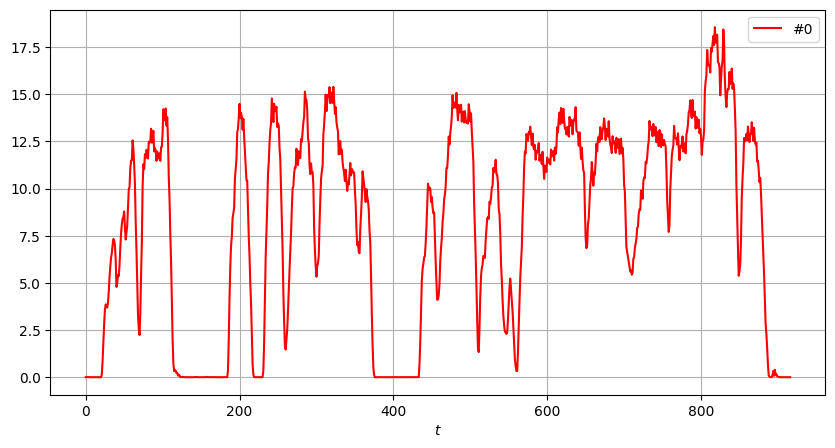

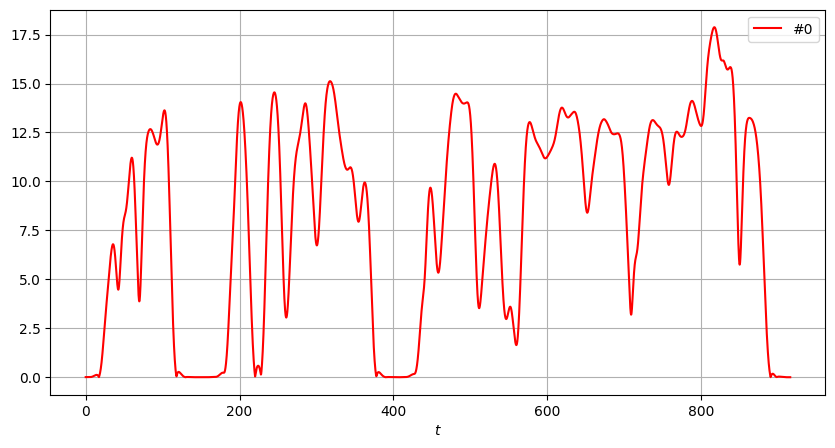

In [18]:
# sebesség nagyság az idő függvényében, eredeti
séta.v_abs=vect_abs(séta.v)
séta.plot_simple([séta.v_abs])

# ugyanez a simítottra
séta_sm.v_abs=vect_abs(séta_sm.v)
séta_sm.plot_simple([séta_sm.v_abs])

Ez sokkal simább, reálisabb függvény.

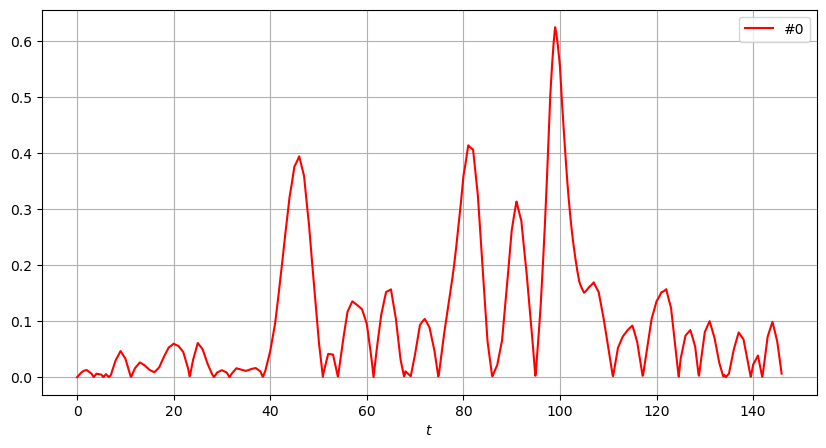

In [15]:
# centripetális gyorsulás nagysága az idő függvényében, simított
séta_sm.plot_simple([np.minimum(séta_sm.a_cp, 10)])

In [16]:
# Mikor volt a legnagyobb a centripetális gyorsulás, azaz mikor kanyarodott a legélesebben a sétáló?

arg_cp_max=séta_sm.a_cp.argmax()
print("Maximális centripetális gyorsulás:")
print(f"   nagysága: {séta_sm.a_cp[arg_cp_max]:.2f} m/s^2")
print(f"   ideje   : {séta_sm.t[arg_cp_max]:.2f} s")
print(f"   helye   : x={séta_sm.r[arg_cp_max,0]:.2f} m;  y={séta_sm.r[arg_cp_max,1]:.2f} m")


Maximális centripetális gyorsulás:
   nagysága: 0.62 m/s^2
   ideje   : 99.00 s
   helye   : x=83.23 m;  y=-16.94 m


## Bizonyos tulajdonságú útszakaszokra való számolás és plottolás

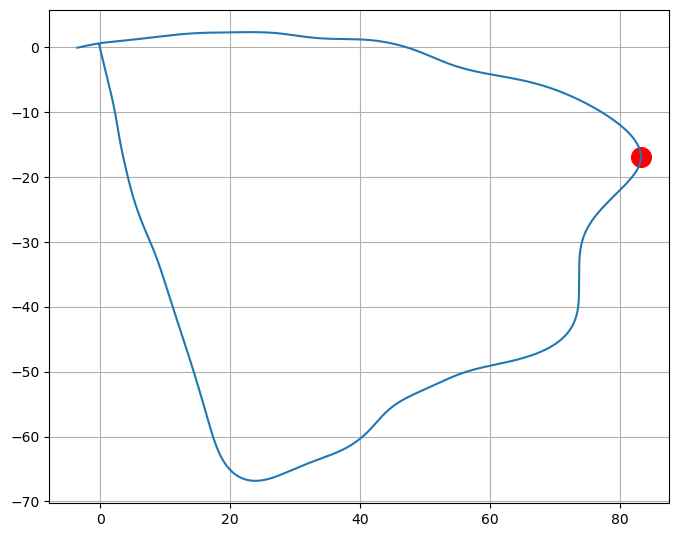

In [17]:
# Jó lenne ezt térképen is látni.
# Megoldás: "scatter", ami pontot vagy pontokat rak ki a grafikonra

fig=plt.figure(figsize=(8,8))  
ax1=plt.subplot(111)

ax1.plot(séta_sm.r[:,0], séta_sm.r[:,1])
# piros korong a max. a_cp helyre:
ax1.scatter(séta_sm.r[arg_cp_max,0], séta_sm.r[arg_cp_max,1], color="red", s=200)  

ax1.set_aspect(aspect='equal')
ax1.grid()


In [18]:
# A 0.3 m/s^2-nél nagyobb centripetális gyorsulású intervallumok:
map_a03=séta_sm.a_cp>0.3  # ez egy True-False térkép

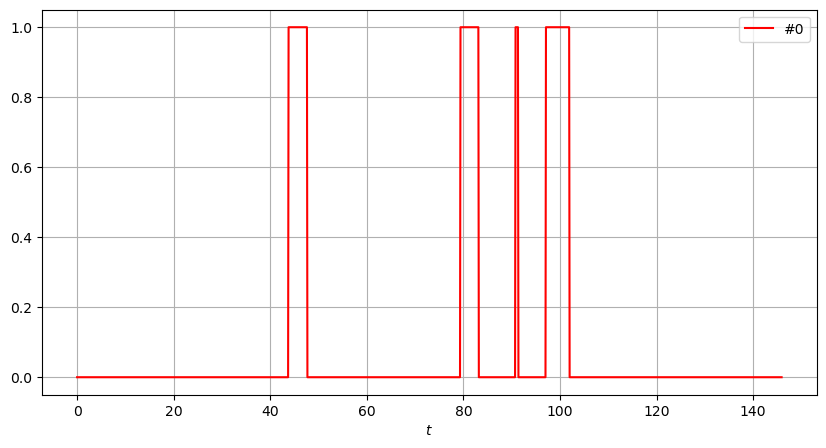

In [19]:
# plottoljuk ki, mely időszakaszokon teljesült ez:
séta_sm.plot_simple([map_a03])
# True=1, False=0

In [20]:
# Össz időtartam: az előző görbe alatti terület
t_map_a03=integ(séta_sm.t, map_a03*1)[-1]  # az össz idő, amíg nagy volt a cp. gyorsulás
# Megjegyzés: map_a03-at azért szoroztam 1-gyel, hogy numerikussá váljon a típusa.

print(f"A centripetális gyorsulás 0.3 m/s^2-nál nagyobb volt {t_map_a03:.2f} s ideig.")

A centripetális gyorsulás 0.3 m/s^2-nál nagyobb volt 13.20 s ideig.


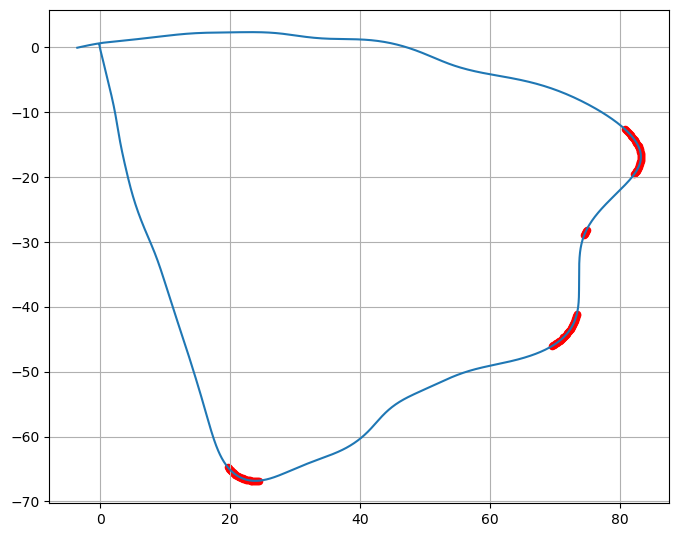

In [21]:
# plottoljuk is ki; sajnos ez nem megy a beépített plot-okkal...
fig=plt.figure(figsize=(8,8))  
ax1=plt.subplot(111)

ax1.plot(séta_sm.r[:,0], séta_sm.r[:,1])  # a pályagörbe
# a pályagörbe nagy a_cp-jű részeinél adatpontok:
ax1.scatter(séta_sm.r[map_a03,0], séta_sm.r[map_a03,1], color="red", s=20)  
ax1.set_aspect(aspect='equal')
ax1.grid()


In [22]:
# Milyen távolságot tett meg ezeken a szakaszokon a test?
# séta_smooth.delta_t_abs : elmozdulás az i. és i+1 időpont közt
# kis igazítás: delta_r_abs eggyel kevesebb elemű, mint a map_a03

path_a03=(séta_sm.delta_r_abs*map_a03[:-1]).sum()

print(f"A nagy cp. gyorsulású szakaszok össz hossza: {path_a03:.2f} m.")

A nagy cp. gyorsulású szakaszok össz hossza: 21.42 m.


In [23]:
# Hány ilyen szakasz volt?
# Sokféle megoldás lehet. Meg kell számolni, map_a03 hányszor vált False-ról True-ra.

delta_map_a03=map_a03[1:]*1 - map_a03[:-1]      # 1-gyel szorzás: True=1, False=0

db_szakasz_a03=(delta_map_a03==1.0).sum()

print(f"A nagy cp. gyorsulású szakaszok darabszáma: {db_szakasz_a03}")

# elfogadott a vizsgán ciklussal végigmenni és nem vektorizáltan számolni meg ezeket a szakaszokat

A nagy cp. gyorsulású szakaszok darabszáma: 4


### Önálló feladatok

1) Állapítsa meg a séta teljes hosszát a simított esetben!

2) Mi volt a legnagyobb mért sebesség nagysága és ekkor hol volt a test? Adja meg koordinátában és grafikusan is.

3) Milyen hosszú ideig volt 50 m-nél távolabb az origótól a test? Rajzolja is ki ezeket a pálya-szakaszokat zölddel!

4) Tekintsük "közel egyenesnek" azokat a szakaszokat, ahol a_cp<0.05. Mennyi ezen szakaszok száma, össz hossza és hol vannak a térképen?

### Vonatozás Kelenföldről Kőbánya-Kispestre

In [24]:
vonat=GPS_to_num_kinem('Kelenföld-Köki.txt', orig='first')
vonat_sm=num_kinem_smooth_r(vonat, 0.1, lam=40, err_report=True)

Adatsor pontosság: RMS=11.441; MAX=15.000
Eltérés          : RMS=1.713; MAX=8.389


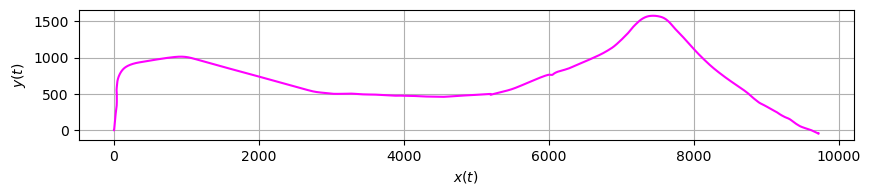

In [25]:
vonat_sm.plot_rcomp(figsize=(10,7))

In [26]:
# Mennyi ideig haladt a vonat 1 m/s-nál lassabban?

vonat_sm.vabs=vect_abs(vonat_sm.v)

map_under1=vonat_sm.vabs<1
t_under1=integ(vonat_sm.t, map_under1*1)[-1]

print(f"A vonat összesen {t_under1:.2f} s-ig haladt 1 m/s-nál lassabban.")

A vonat összesen 190.85 s-ig haladt 1 m/s-nál lassabban.


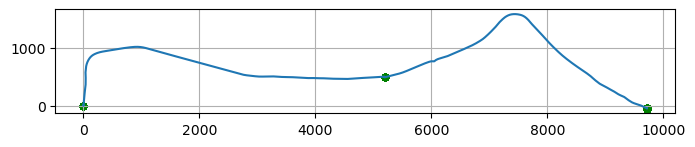

In [27]:
# hol vannak ezek a lassú helyek a térképen?

fig=plt.figure(figsize=(8,8))  
ax1=plt.subplot(111)

ax1.plot(vonat_sm.r[:,0], vonat_sm.r[:,1])
ax1.scatter(vonat_sm.r[map_under1,0], vonat_sm.r[map_under1,1], color="green", s=20)

ax1.set_aspect(aspect='equal')
ax1.grid()

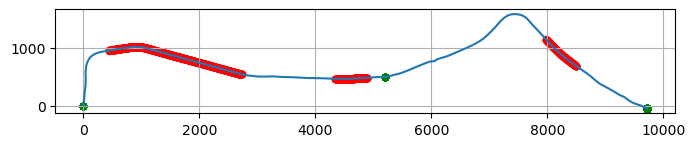

In [28]:
# Erre tegyük rá még pirossal a 20 m/s-nál gyorsabb helyeket:
map_over20=vonat_sm.vabs>20

fig=plt.figure(figsize=(8,8))  
ax1=plt.subplot(111)

ax1.plot(vonat_sm.r[:,0], vonat_sm.r[:,1])
ax1.scatter(vonat_sm.r[map_under1,0], vonat_sm.r[map_under1,1], color="green", s=20)
ax1.scatter(vonat_sm.r[map_over20,0], vonat_sm.r[map_over20,1], color="red", s=20)

ax1.set_aspect(aspect='equal')
ax1.grid()

### Önálló feladatok

4. Nevezzük "éles kanyarnak" az 0.5 m/s^2-nél nagyobb centripetális gyorsulású időpontokat. Hol vannak ezek a térképen, mennyi az össz időtartama és össz hosszuk?

5. Nevezzük "erős fékezésnek" a -0.5 m/s^2-nél alacsonyabb tangenciális gyorsulású időpontokat. Hol vannak ezek a térképen, mennyi az össz időtartama és össz hosszuk?

## Út-sebesség grafikon alapú problémák

Sok gyakorlati kérdésben nem az idő, hanem a megtett út, azaz az útvonalon belüli pozíció az érdekes.

Ezt legeneráljuk a 'pathlength' részbe.

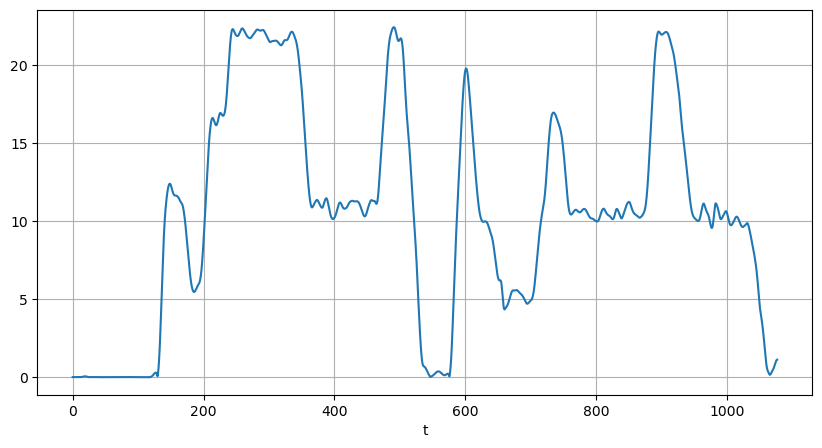

In [29]:
# A vonat sebesség-nagyság-idő függvénye:
fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vonat_sm.t, vonat_sm.vabs)
ax1.set_xlabel('t')

ax1.grid()

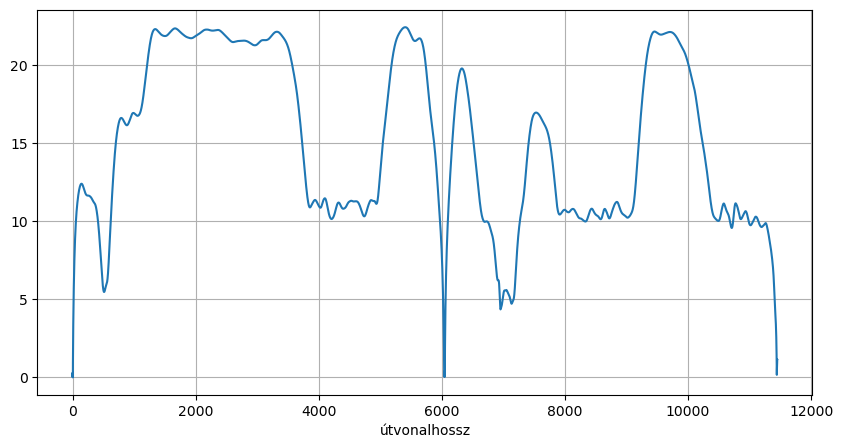

In [30]:
# A vonat sebesség-nagyság-útvonalhossz függvénye:
fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vonat_sm.pathlength, vonat_sm.vabs)
ax1.set_xlabel('útvonalhossz')

ax1.grid()

Látható: pl. az állomás egy pontra húzódik össze.

(-572.4078236952132, 12020.564297599478)

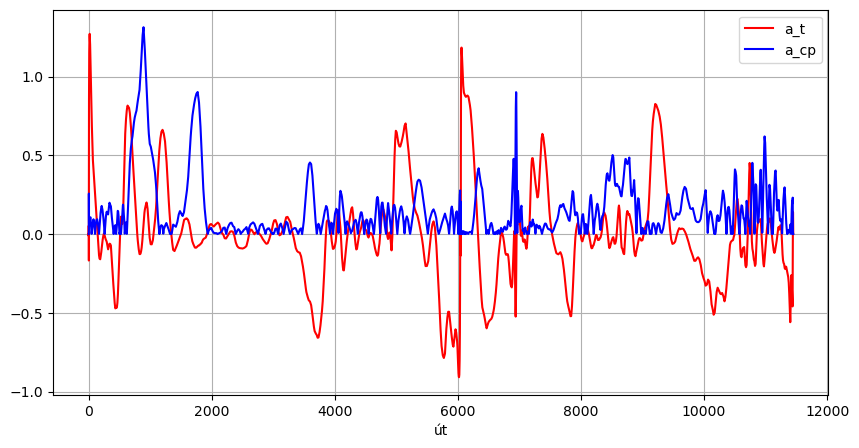

In [31]:
# a_t az út függvényében:

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vonat_sm.pathlength, vonat_sm.a_t, color="red", label="a_t")
ax1.plot(vonat_sm.pathlength, vonat_sm.a_cp, color="blue", label="a_cp")
ax1.set_xlabel('út')

ax1.grid()
ax1.legend(loc='upper right')

ax1.set_xlim([None,None]) # Ha csak egy tartomány érdekel, akkor a None-ok helyett értéket írhatunk be.
#ax1.set_xlim([0,3000]) 
# a_t>0: gyorsít a vonat, a_t<0: lassít a vonat
# a_cp nagy: kanyarodik a vonat

In [32]:
# Mennyi volt a menetidő?

print(f"Menetidő: {vonat_sm.t[-1]-vonat_sm.t[0]:.1f} s.")

Menetidő: 1076.9 s.


Mennyi lett volna a menetidő, ha nem mehetett volna sehol 15 m/snál gyorsabban?

Visszafelé kell gondolkodni: 
1) kiszámolni vabs-ot 
2) kiszámolni delta_t-k és delta_s-ek táblázatát
3) ahol vabs>15, ott visszavenni 15-re és korrigálni delta_t-ket
4) delta_t-k összege az új menetidő


In [33]:
vabs_work=vect_abs(vonat_sm.v)[:-1] # az utolsót lehagyjuk, mert az már a vége utánra számítana
dt_work=vonat_sm.t[1:]-vonat_sm.t[:-1]
ds_work=vonat_sm.pathlength[1:]-vonat_sm.pathlength[:-1]
# most korrigáljuk a sebességet:
vabs_korr=np.minimum(vabs_work, 15)
# korrigáljuk a menetidőt:
dt_korr=dt_work*vabs_work/vabs_korr

print("Menetidő:")
print(f"  -eredeti: {dt_work.sum():.1f} s")
print(f"  -v<15   : {dt_korr.sum():.1f} s")

Menetidő:
  -eredeti: 1076.9 s
  -v<15   : 1168.6 s


## Önálló problémák

**1. probléma:** A mellékelt "seta-busz.txt" egy olyan esetet mutat be, ami sétával kezdődik, majd buszozással folytatódik.

   1) Mekkora a teljes út hossza, átlagos sebességnagysága?
   2) Az időtartam hány százalékában haladt az ember 1 m/s-nál lassabban?
   3) Jelenítse meg az 5 m/s-nál gyorsabb szakaszokat az útvonal-térképen!
   4) Mikortól kezdődhetett a buszozás?
   5) Mennyi az átlagos sebesség-nagyság a buszozás és a gyaloglás tartama alatt?
   6) Mennyi az átlagsebesség nagysága  a buszozás és a gyaloglás tartama alatt?
   7) Mi volt a legnagyobb fékezés? Adja meg az ekkor mért tangenciális gyorsulás értékét (a_t_abs) és jelölje ennek helyét a térképen.

**2. probléma:** A mellékelt "szerviz-egyetem.txt" egy autóvezetés GPS-logja. 

1) Ha ez a vezetés lakott területen történt akkor mennyi ideig és milyen hosszú szakaszon lépte át a sofőr az 50 km/h sebességhatárt?

2) Mennyi menetidőt spórolt a sofőr a gyorshajtással? Azaz mennyi most a menetidő és mennyi lett volna, ha mindenütt legfeljebb 50 km/h-val halad?

3) Jelenítse meg az út függvényében a sebesség abszolútértékét!

4) Mi volt a legnagyobb tangenciális és centripetális gyorsulás-érték?

5) Hányszor állt meg az autó az időszakasz alatt? 